In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pasp_normalized_df = pd.read_csv("../data/processed/pasp_normalized_df.csv")
pasp_normalized_df["sample_nr"] = [s[:3] for s in pasp_normalized_df["sample"]]
pasp_normalized_df["filter"] = [s[-3:] for s in pasp_normalized_df["sample"]]

C:\Users\pierr\AppData\Local\Temp\ipykernel_15540\3910810060.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pasp_normalized_df["sample_nr"] = [s[:3] for s in pasp_normalized_df["sample"]]
C:\Users\pierr\AppData\Local\Temp\ipykernel_15540\3910810060.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pasp_normalized_df["filter"] = [s[-3:] for s in pasp_normalized_df["sample"]]


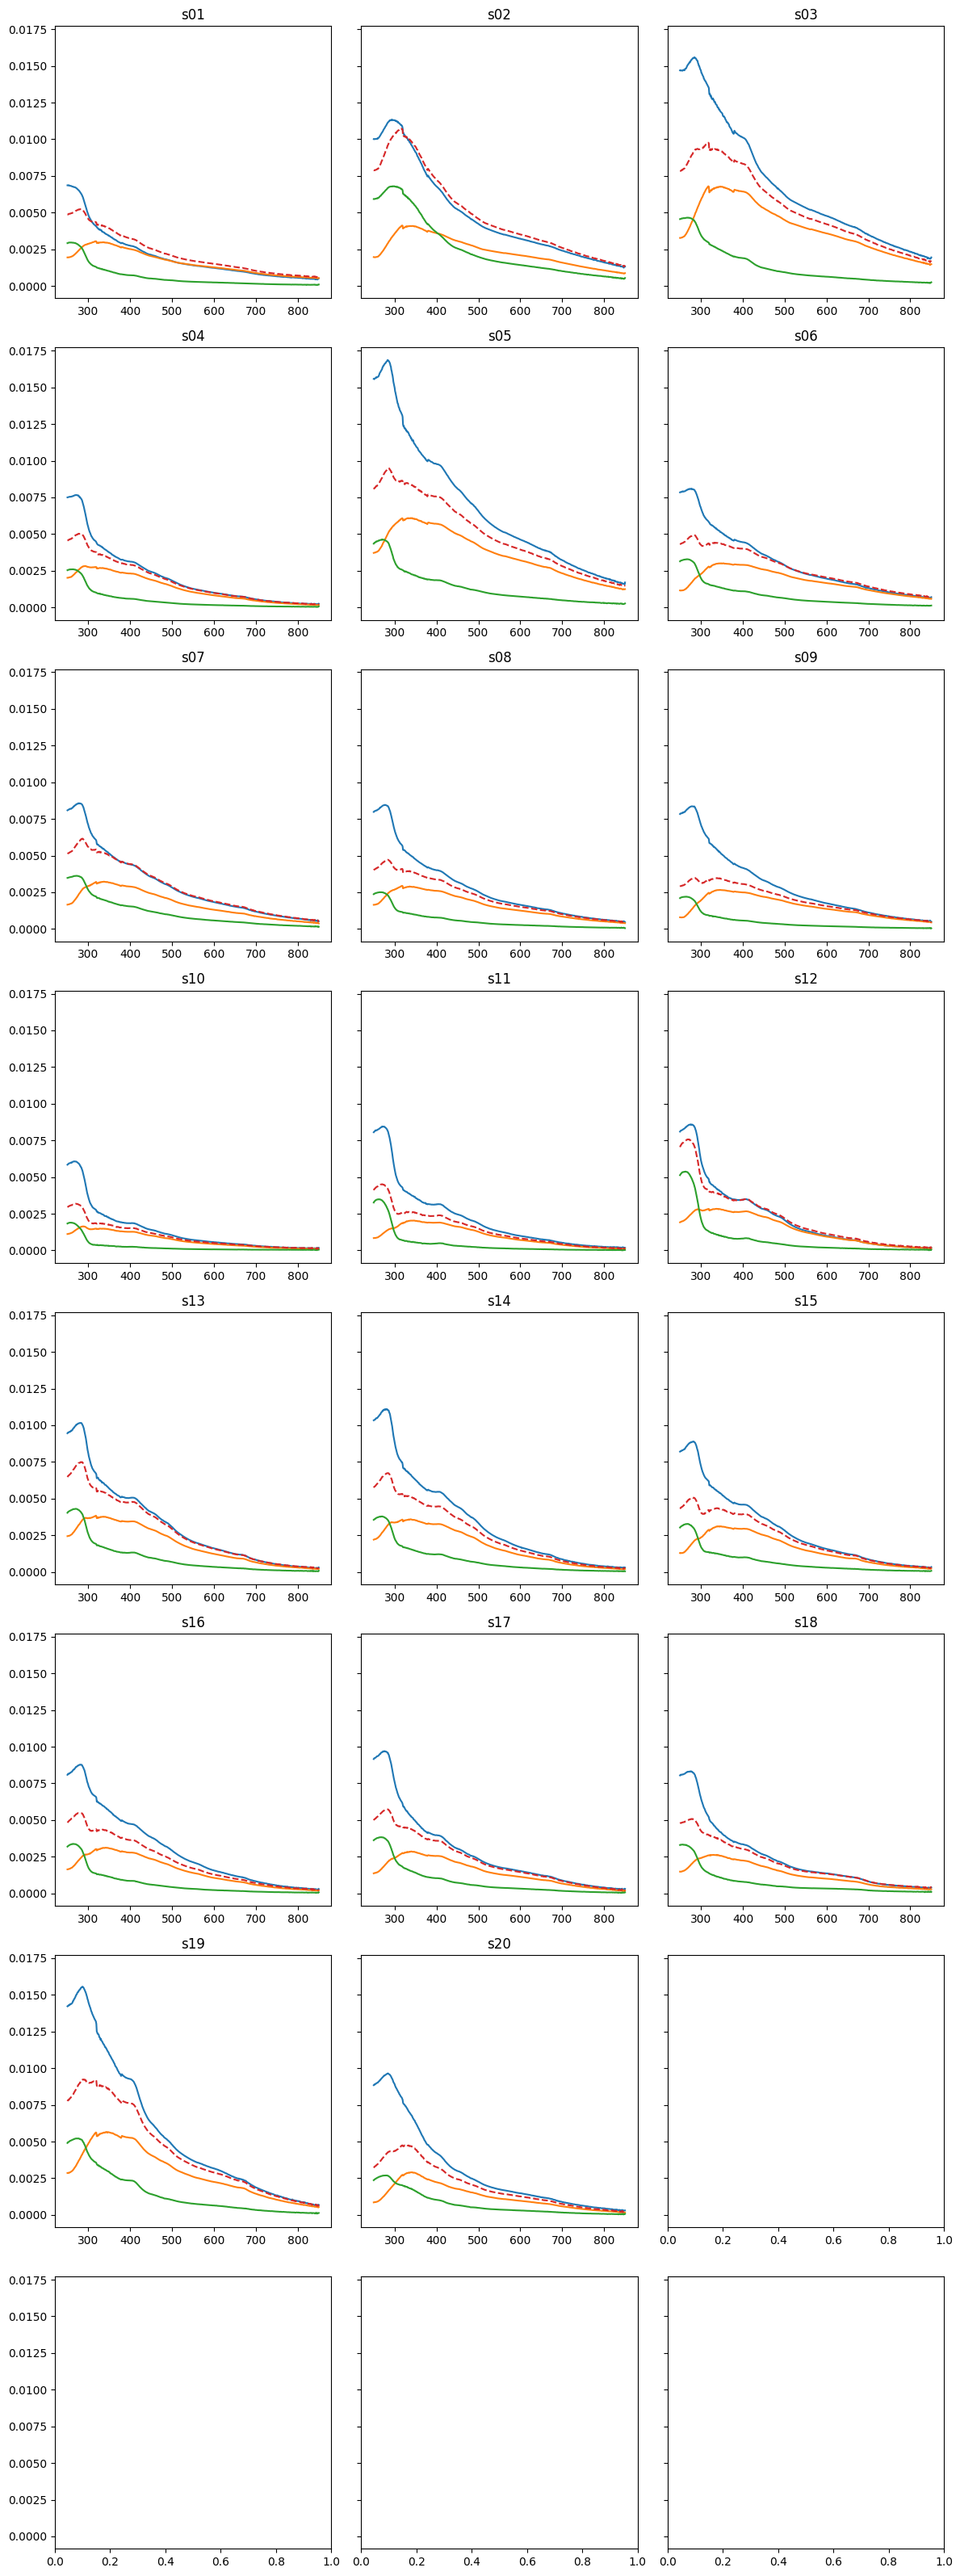

In [5]:
wav = pasp_normalized_df.columns[1:-2].astype("float")

sample_nr_list = pasp_normalized_df["sample_nr"].unique()

fig, ax = plt.subplots(ncols=3, nrows=8, figsize=(12, 32), sharey=True)

for (i, sample_nr) in enumerate(sample_nr_list):

    sp_raw = pasp_normalized_df[pasp_normalized_df["sample"]==f"{sample_nr}_raw"].values[0][1:-2]
    sp_15u = pasp_normalized_df[pasp_normalized_df["sample"]==f"{sample_nr}_14u"].values[0][1:-2]
    sp_05u = pasp_normalized_df[pasp_normalized_df["sample"]==f"{sample_nr}_04u"].values[0][1:-2]

    sp_calc = sp_15u+sp_05u

    ii = i//3
    jj = i%3

    ax[ii, jj].plot(wav, sp_raw, label="raw")
    ax[ii, jj].plot(wav, sp_15u, label="sp_15u")
    ax[ii, jj].plot(wav, sp_05u, label="sp_05u")
    ax[ii, jj].plot(wav, sp_calc, linestyle="--", label="15u+05u")
    ax[ii, jj].set_title(sample_nr)
    

plt.tight_layout()
plt.show()





**comment**
26-02-19. I did not anticipate the discrepancies between sum and raw filter, but this is a known phenomenon. I need to five into some literature to understand this better. Probably I need to show this to Daniel to start the discussion

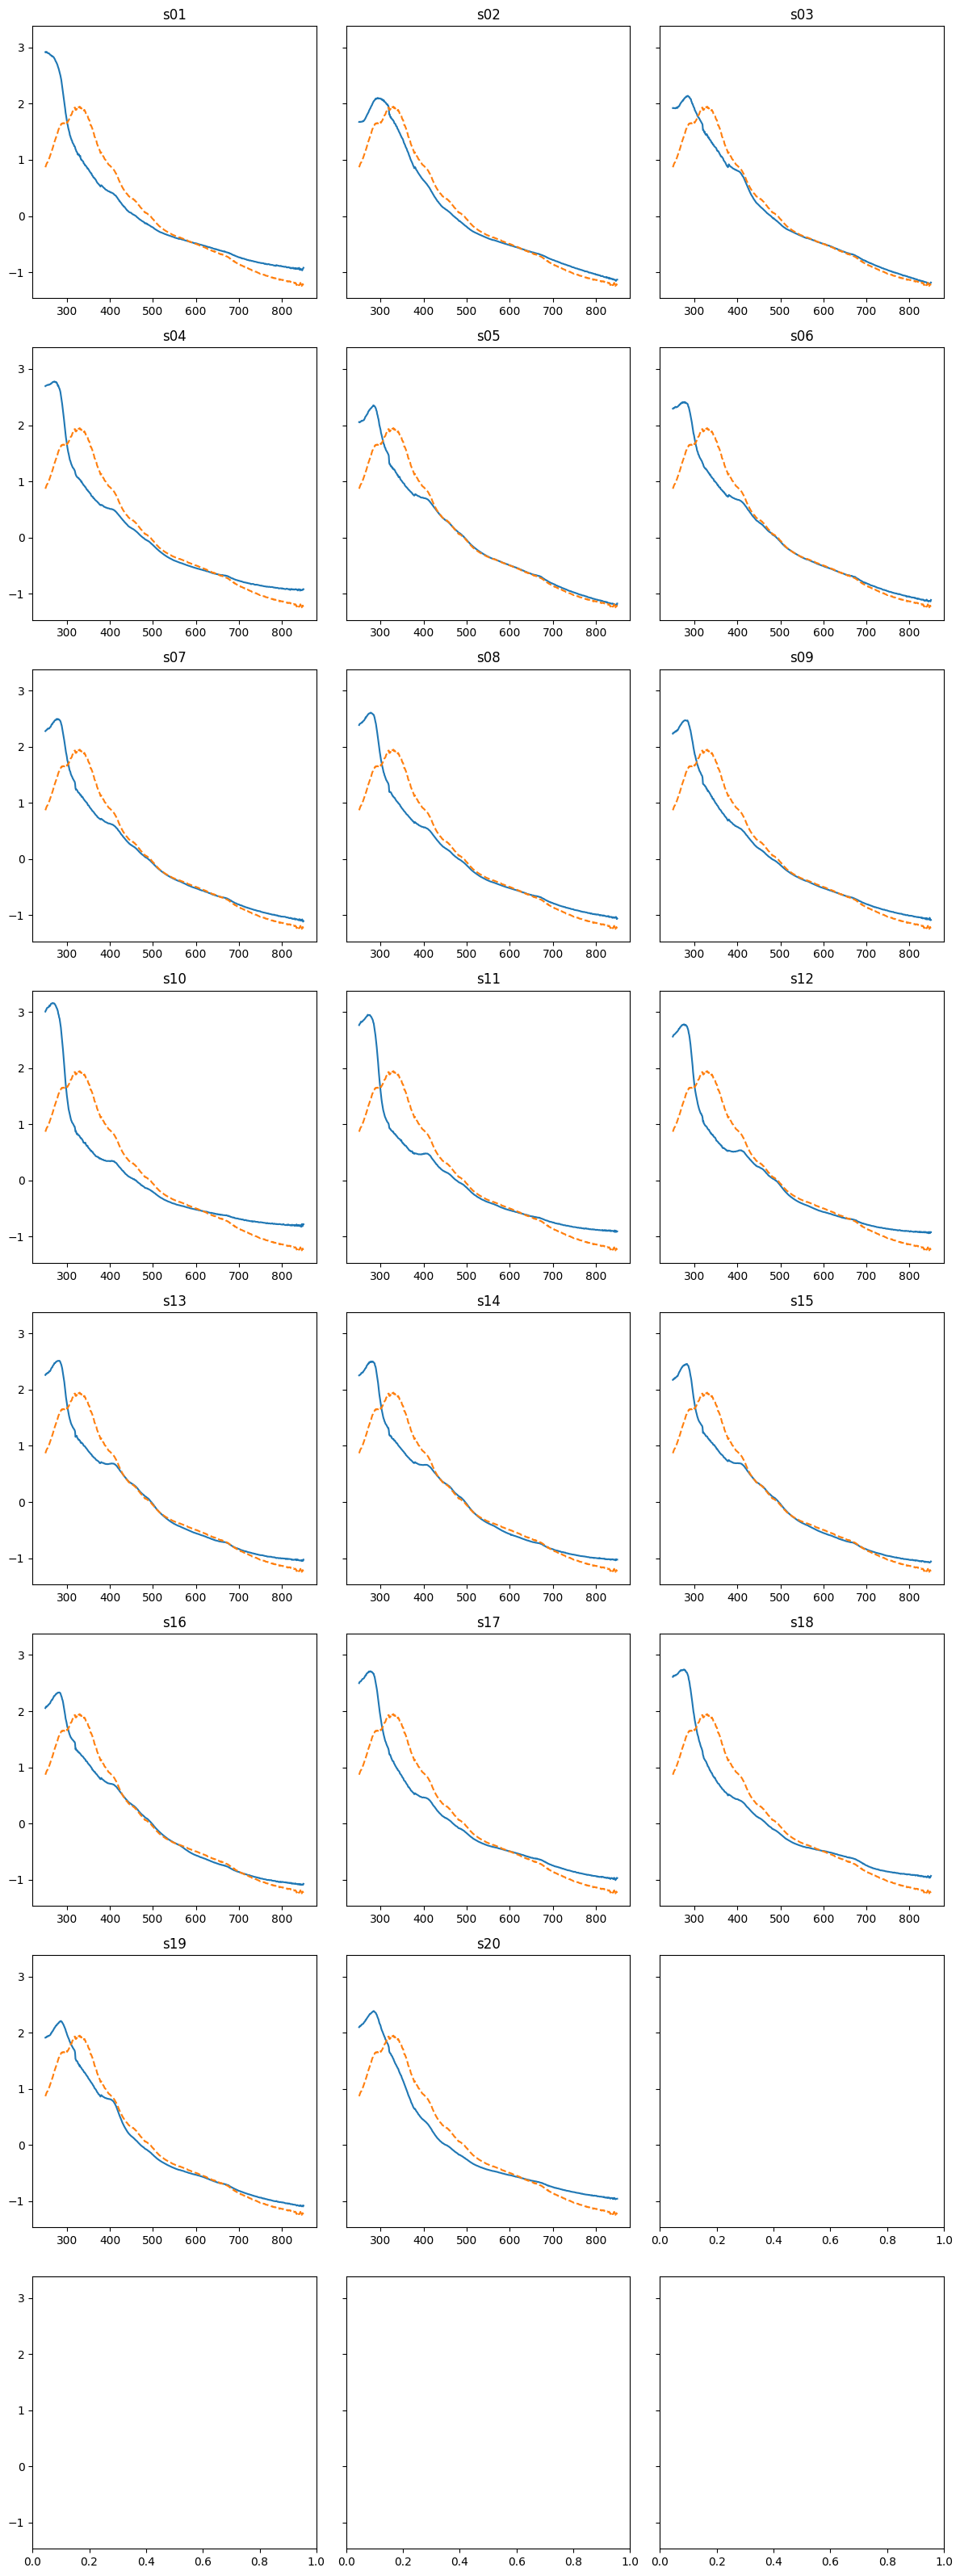

In [7]:
wav = pasp_normalized_df.columns[1:-2].astype("float")

sample_nr_list = pasp_normalized_df["sample_nr"].unique()

fig, ax = plt.subplots(ncols=3, nrows=8, figsize=(12, 32), sharey=True)

for (i, sample_nr) in enumerate(sample_nr_list):

    sp_raw = pasp_normalized_df[pasp_normalized_df["sample"]==f"{sample_nr}_raw"].values[0][1:-2]
    sp_raw_norm = ( sp_raw-sp_raw.mean() ) / ( sp_raw.std() )

    sp_calc = sp_15u+sp_05u
    sp_calc_norm = ( sp_calc-sp_calc.mean() ) / ( sp_calc.std() )

    ii = i//3
    jj = i%3

    ax[ii, jj].plot(wav, sp_raw_norm, label="raw std_norm")
    ax[ii, jj].plot(wav, sp_calc_norm, linestyle="--", label="15u+05u std_norm")
    ax[ii, jj].set_title(sample_nr)
    

plt.tight_layout()
plt.show()



